In [1]:
import sys
import os

sys.path.append(os.path.abspath("../src"))
from training.train import train

train()



Using device: cpu


c:\Users\Hp\OneDrive\Desktop\chest-xray-ai\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Hp\OneDrive\Desktop\chest-xray-ai\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Epoch 1, Training Loss: 56.6045

Confusion Matrix:
[[3 5]
 [0 8]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.38      0.55         8
           1       0.62      1.00      0.76         8

    accuracy                           0.69        16
   macro avg       0.81      0.69      0.65        16
weighted avg       0.81      0.69      0.65        16



In [2]:
import torch
print(torch.cuda.is_available())

False


In [2]:
sys.path.append(os.path.abspath("../src"))
from models.model import get_model

model = get_model()
print(model)

c:\Users\Hp\OneDrive\Desktop\chest-xray-ai\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Hp\OneDrive\Desktop\chest-xray-ai\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to C:\Users\Hp/.cache\torch\hub\checkpoints\densenet121-a639ec97.pth


100.0%

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [3]:
from PIL import Image

img = Image.open("../data/chest_xray/train/NORMAL/IM-0115-0001.jpeg")

transformed_img = train_transform(img)

print(transformed_img.shape)

torch.Size([1, 224, 224])


In [4]:
sys.path.append(os.path.abspath("../src"))

from dataset.loader import get_dataloaders

train_loader, val_loader = get_dataloaders("../data/chest_xray")

In [5]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [3]:
train_normal_path = "../data/chest_xray/train/NORMAL"
train_pneumonia_path = "../data/chest_xray/train/PNEUMONIA"

(np.float64(-0.5), np.float64(2089.5), np.float64(1857.5), np.float64(-0.5))

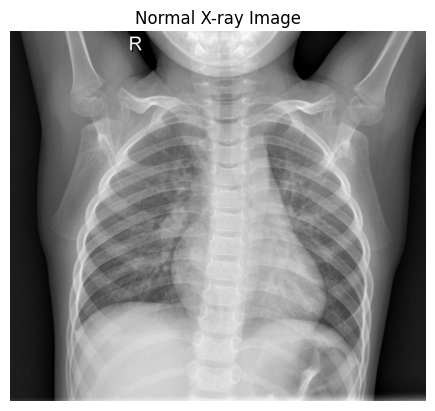

In [4]:
img_path = os.listdir(train_normal_path)[0]
img = Image.open(os.path.join(train_normal_path, img_path))
plt.imshow(img, cmap="gray")
plt.title("Normal X-ray Image")
plt.axis("off")

(np.float64(-0.5), np.float64(1151.5), np.float64(759.5), np.float64(-0.5))

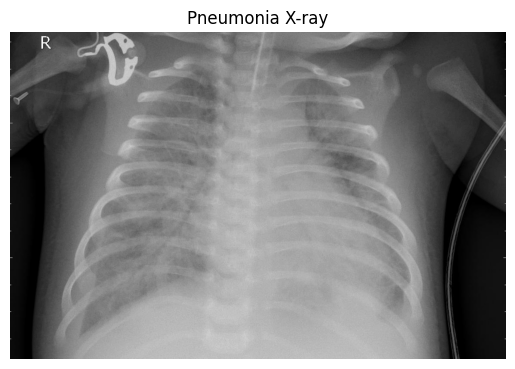

In [5]:
img_path = os.listdir(train_pneumonia_path)[0]

img = Image.open(os.path.join(train_pneumonia_path, img_path))

plt.imshow(img, cmap="gray")
plt.title("Pneumonia X-ray")
plt.axis("off")

In [1]:
import random

def show_images(folder, title):

    images = os.listdir(folder)

    plt.figure(figsize=(10,6))

    for i in range(6):

        img_path = random.choice(images)

        img = Image.open(os.path.join(folder, img_path))

        plt.subplot(2,3,i+1)
        plt.imshow(img, cmap="gray")
        plt.axis("off")

    plt.suptitle(title)

In [7]:
print(img.size)

(1152, 760)
